# Random Forest Classifier - Refactored

This notebook implements a Random Forest Classifier using a modular approach with `DataProcessor` and `ModelTrainer` classes.

In [5]:
import sys
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Add parent directory to path to find ml_core package
sys.path.append(os.path.abspath(".."))

from ml_core.data_processor import DataProcessor
from ml_core.model_trainer import ModelTrainer

## 1. Data Preprocessing

We use the `DataProcessor` class to load, clean, and split the data.

In [6]:
# Initialize DataProcessor
processor = DataProcessor("../Data/CareerMapping1.csv")

# Load and Preprocess (Target: Role)
X, y = processor.preprocess()

# Get label mapping
label_mapping = processor.get_label_mapping()
print("Roles Mapping:", label_mapping)

# Split data into 50% Train, 20% Val, 30% Test
X_train, X_val, X_test, y_train, y_val, y_test = processor.split_data(test_size=0.3, val_size=0.2)

Roles Mapping: {0: 'AI ML Specialist', 1: 'API Specialist', 2: 'Application Support Engineer', 3: 'Business Analyst', 4: 'Customer Service Executive', 5: 'Cyber Security Specialist', 6: 'Database Administrator', 7: 'Graphics Designer', 8: 'Hardware Engineer', 9: 'Helpdesk Engineer', 10: 'Information Security Specialist', 11: 'Networking Engineer', 12: 'Project Manager', 13: 'Software Developer', 14: 'Software tester', 15: 'Technical Writer'}


## 2. Model Training and Evaluation

We use the `ModelTrainer` class with a `RandomForestClassifier` model.

In [7]:
# Initialize ModelTrainer with Random Forest
trainer = ModelTrainer(RandomForestClassifier(n_estimators=100, random_state=42))

# Train the model
trainer.train(X_train, y_train)

# Evaluate on Train Set
trainer.evaluate(X_train, y_train, "Train")

# Evaluate on Validation Set
trainer.evaluate(X_val, y_val, "Validation")

# Evaluate on Test Set
accuracy, y_pred = trainer.evaluate(X_test, y_test, "Test")

Accuracy on Train set: 1.0000
Accuracy on Validation set: 0.9052
Accuracy on Test set: 0.9119


## 3. Detailed Performance Metrics


Classification Report:
                                 precision    recall  f1-score   support

               AI ML Specialist       0.98      0.94      0.96       337
                 API Specialist       0.85      0.90      0.88       168
   Application Support Engineer       0.91      0.89      0.90       204
               Business Analyst       0.90      0.93      0.92       182
     Customer Service Executive       0.94      0.94      0.94       176
      Cyber Security Specialist       0.95      0.90      0.92       178
         Database Administrator       0.75      0.93      0.83       199
              Graphics Designer       0.88      0.92      0.90       194
              Hardware Engineer       0.97      0.92      0.94       181
              Helpdesk Engineer       0.93      0.92      0.93       163
Information Security Specialist       0.96      0.88      0.92       190
            Networking Engineer       0.86      0.91      0.88       169
                Project Ma

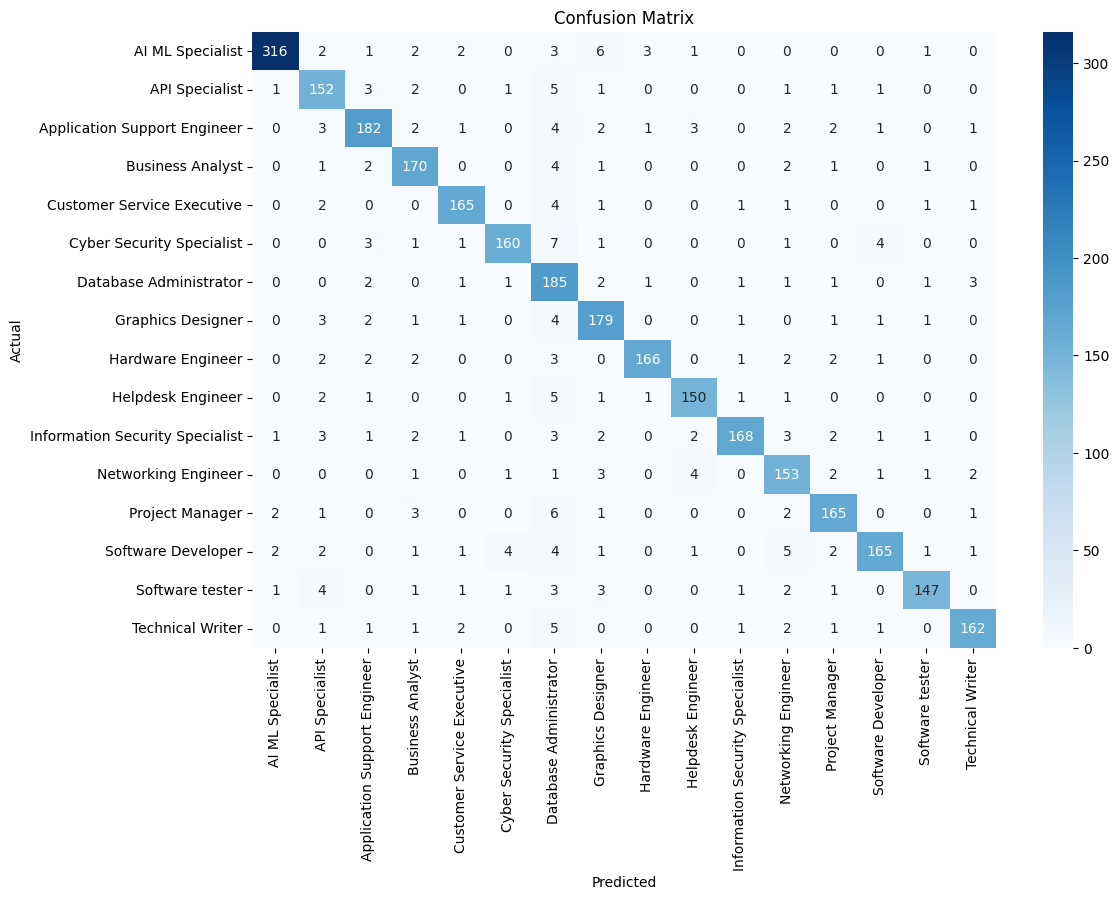

In [8]:
# Print Classification Report
trainer.print_classification_report(y_test, y_pred, target_names=list(label_mapping.values()))

# Plot Confusion Matrix
trainer.plot_confusion_matrix(y_test, y_pred, labels=list(label_mapping.values()))